# Age-wise Dynamics of Aadhaar Enrolment and Updates

## 1. Motivation and Hypothesis
Aadhaar activity varies significantly across age groups due to lifecycle effects, policy mandates, and system maturity. While the system's early years were defined by rapid enrolment, the current phase is characterized by maintenance. 

**Our Primary Hypothesis:**
In a mature identity system, the operational load shifts from **Identity Creation** (Enrolment) to **Identity Lifecycle Management** (Biometric and Demographic Updates). We expect this shift to be most visible in the school-age (**5–17**) demographic due to school-linked drives and mandatory biometric capture policies.

## 2. Analytical Scope
This notebook analyzes national and state-level data across three primary cohorts:
* **0–5 years**: Early childhood enrolment.
* **5–17 years**: Transition phase (school age).
* **18+ years**: Adult Aadhaar usage.

## 3. Data Sources
- Aadhaar Enrolment Dataset
- Aadhaar Demographic Update Dataset
- Aadhaar Biometric Update Dataset

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)

fact_enrolment = pd.read_csv("../data/cleaned/fact_enrolment.csv")
fact_demographic = pd.read_csv("../data/cleaned/fact_demographic.csv")
fact_biometric   = pd.read_csv("../data/cleaned/fact_biometric.csv")

fact_enrolment.shape, fact_demographic.shape, fact_biometric.shape

((1006007, 7), (2071698, 6), (1861108, 6))

In [120]:
# National Age-wise Overview
age_df = pd.DataFrame({
    "Age Group": ["0–5", "5–17", "18+"],
    "Enrolments": [
        fact_enrolment["age_0_5"].sum(),
        fact_enrolment["age_5_17"].sum(),
        fact_enrolment["age_18_greater"].sum()
    ],
    "Demographic Updates": [
        0,
        fact_demographic["demo_age_5_17"].sum(),
        fact_demographic["demo_age_17_"].sum()
    ],
    "Biometric Updates": [
        0,
        fact_biometric["bio_age_5_17"].sum(),
        fact_biometric["bio_age_17_"].sum()
    ]
})

age_df


,Age Group,Enrolments,Demographic Updates,Biometric Updates
0,0–5,3546965,0,0
1,5–17,1720383,4863424,34226855
2,18+,168136,44431761,35536240


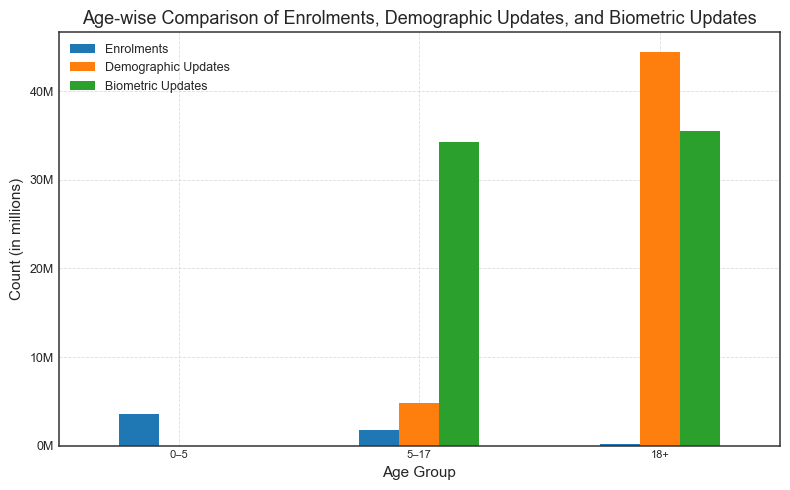

In [121]:
# Plot (same as before)
ax = age_df.set_index("Age Group").plot(
    kind="bar",
    figsize=(8, 5)
)

# Title and labels
ax.set_title(
    "Age-wise Comparison of Enrolments, Demographic Updates, and Biometric Updates"
)
ax.set_xlabel("Age Group")
ax.set_ylabel("Count (in millions)")

# Format y-axis to show millions (M)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1_000_000)}M")
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [122]:
# Update Pressure per Enrolment (Age-wise)
age_df["Demo Updates per Enrolment"] = (
    age_df["Demographic Updates"] / age_df["Enrolments"]
)

age_df["Bio Updates per Enrolment"] = (
    age_df["Biometric Updates"] / age_df["Enrolments"]
)

age_df.replace([np.inf, np.nan], 0, inplace=True)
age_df


,Age Group,Enrolments,Demographic Updates,Biometric Updates,Demo Updates per Enrolment,Bio Updates per Enrolment
0,0–5,3546965,0,0,0.000000,0.000000
1,5–17,1720383,4863424,34226855,2.826943,19.894904
2,18+,168136,44431761,35536240,264.260842,211.354142


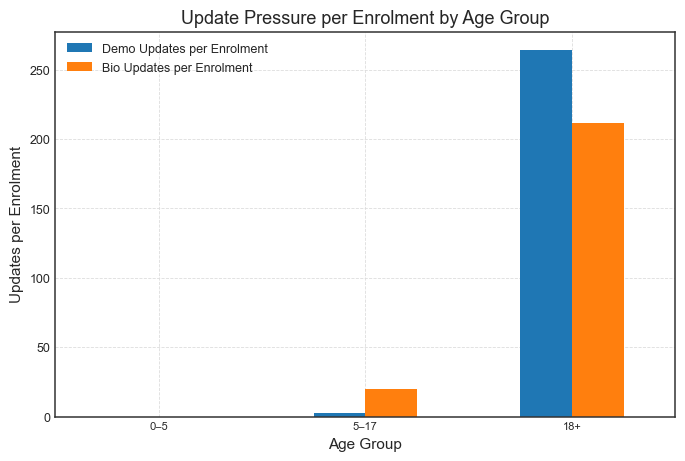

In [123]:
age_df.set_index("Age Group")[
    ["Demo Updates per Enrolment", "Bio Updates per Enrolment"]
].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Update Pressure per Enrolment by Age Group")
plt.ylabel("Updates per Enrolment")
plt.xticks(rotation=0)
plt.show()


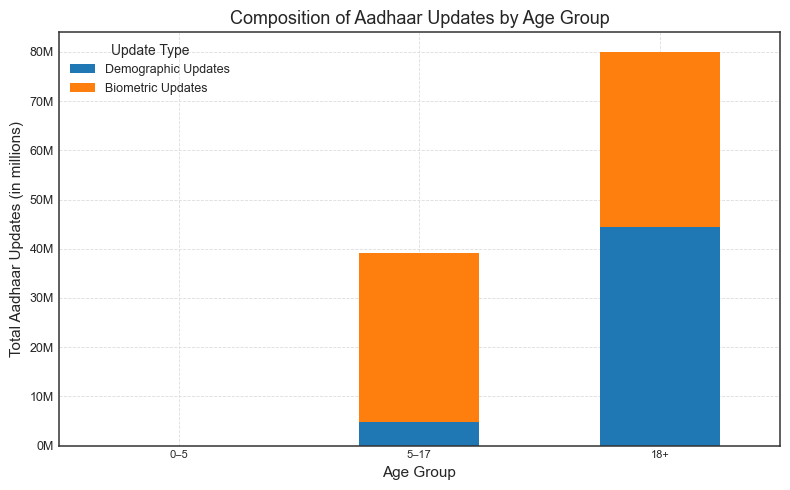

In [124]:
ax = age_df.set_index("Age Group")[
    ["Demographic Updates", "Biometric Updates"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

# Titles and labels
ax.set_title("Composition of Aadhaar Updates by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Total Aadhaar Updates (in millions)")

# Format y-axis to show millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1_000_000)}M")
)

# Legend
ax.legend(
    title="Update Type",
    labels=["Demographic Updates", "Biometric Updates"]
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Insight 1: Quantifying the Shift to Maintenance
The data for the **5–17 age group** confirms a clear hierarchy: **Enrolments < Demographic Updates < Biometric Updates**.

### **Detailed Macro Analysis**
* **Enrolments are Lowest**: This indicates that the Aadhaar program has reached a **mature stage**, with fewer new individuals entering the system. Most of the eligible population is already enrolled, leading to a natural taper in new enrolments.
* **Demographic Updates are Moderate**: While citizens update addresses, phone numbers, and other details, these are secondary (~4.86M) to biometric activities. They appear to be event-driven and largely optional compared to biometric refreshes.
* **Biometric Updates Dominate**: This is the highest activity (~34.22M), being nearly **20 times more frequent** than new enrolments in this age bracket. 

> **Key Takeaway**: The 5-17 cohort represents the "Update Pressure" peak of the Aadhaar system, driven by mandatory age-based biometric re-capture policies at age 5 and 15.

### Transition to State-wise Age Dynamics
While national age-wise patterns explain overall biometric dominance, state-level
variation helps identify regions where update pressure is particularly concentrated.
The following analysis examines age-driven Aadhaar activity across all states.

In [125]:
state_enrol_5_17 = (
    fact_enrolment.groupby("state", as_index=False)
    .agg(enrol_5_17=("age_5_17", "sum"))
)

state_demo_5_17 = (
    fact_demographic.groupby("state", as_index=False)
    .agg(demo_5_17=("demo_age_5_17", "sum"))
)

state_bio_5_17 = (
    fact_biometric.groupby("state", as_index=False)
    .agg(bio_5_17=("bio_age_5_17", "sum"))
)

state_5_17 = (
    state_enrol_5_17
    .merge(state_demo_5_17, on="state", how="left")
    .merge(state_bio_5_17, on="state", how="left")
)

state_5_17.fillna(0, inplace=True)
state_5_17


,state,enrol_5_17,demo_5_17,bio_5_17
0,andaman and nicobar islands,32,617,11806
1,andhra pradesh,13746,321148,2241467
2,arunachal pradesh,2236,5783,42894
3,assam,66085,84480,596624
4,bihar,334802,380023,2208141
5,chandigarh,211,13133,49171
6,chhattisgarh,18769,165207,884555
7,dadra and nagar haveli and daman and diu,250,1923,16362
8,delhi,22296,175535,556237
9,goa,254,3275,34244


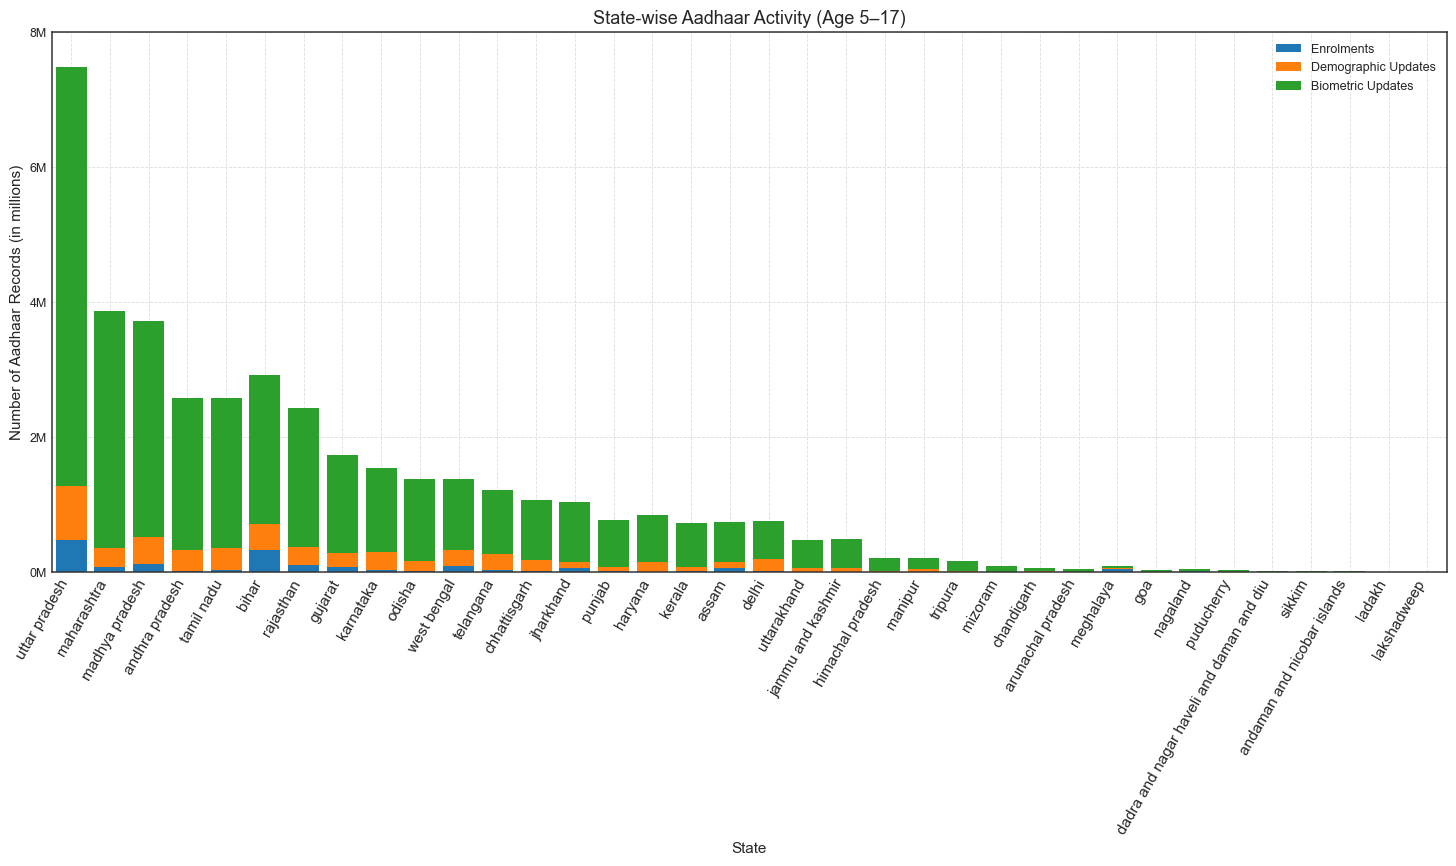

In [133]:
state_5_17_sorted = state_5_17.sort_values("bio_5_17", ascending=False)

fig, ax = plt.subplots(figsize=(18, 9))


# Stacked bars
ax.bar(
    state_5_17_sorted["state"],
    state_5_17_sorted["enrol_5_17"],
    label="Enrolments"
)

ax.bar(
    state_5_17_sorted["state"],
    state_5_17_sorted["demo_5_17"],
    bottom=state_5_17_sorted["enrol_5_17"],
    label="Demographic Updates"
)

ax.bar(
    state_5_17_sorted["state"],
    state_5_17_sorted["bio_5_17"],
    bottom=(
        state_5_17_sorted["enrol_5_17"]
        + state_5_17_sorted["demo_5_17"]
    ),
    label="Biometric Updates"
)

# Titles and labels
ax.set_title("State-wise Aadhaar Activity (Age 5–17)")
ax.set_xlabel("State")
ax.set_ylabel("Number of Aadhaar Records (in millions)")

# 🔑 FORCE 0M → 8M range
ax.set_ylim(0, 8_000_000)

# 🔑 FORCE ticks: 0, 2, 4, 6, 8 M
ax.yaxis.set_major_locator(MultipleLocator(2_000_000))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x/1_000_000)}M")
)

# Layout fixes (bars > labels)
ax.set_xlim(-0.5, len(state_5_17_sorted) - 0.5)
plt.xticks(rotation=60, ha="right", fontsize=11)
plt.subplots_adjust(bottom=0.28)

ax.legend()
plt.show()


## 5. Insight 2: The Delayed Adoption Pattern
State-level analysis reveals that the national trend is not uniform. Several states show higher enrolment volumes in the 5–17 group compared to the 0–5 group.

### **Regional Dynamics**
* **Delayed Enrolment**: In many regions, a significant portion of the population appears to defer enrolment until school age. 
* **Concentrated Pressure**: This delay causes a "double-load" on infrastructure in these states—simultaneously managing initial enrolment and mandatory biometric refreshes for students.
* **Operational Variance**: States like Uttar Pradesh and Madhya Pradesh show extreme biometric update counts, indicating where the burden on local UIDAI centers is most intense.

## 6. Summary Conclusion: The Biometric-Centric Identity Lifecycle



The data hierarchy confirms that Aadhaar is no longer an enrolment-heavy program but a **biometric maintenance ecosystem**. For the critical 5–17 demographic, the system processes **20 biometric updates for every one new enrolment**. This dominance is driven by lifecycle management and delayed enrolment rather than frequent identity changes.

###  **Strategic Implications for UIDAI**

* **Operational Focus**: Resources should be strategically directed toward biometric infrastructure, including high-resolution devices and specialized staff training, particularly in school districts with high update pressure.
* **Risk Management**: Sustained high biometric update volumes, particularly in specific states, can serve as an indicator for monitoring data integrity and fraud prevention effectiveness.
* **Citizen Experience**: To reduce citizen inconvenience, development should focus on improving the quality of the **initial capture** at the time of enrolment to minimize future re-captures.
* **Forecasting and Planning**: UIDAI should project future server loads and infrastructure needs based on biometric re-capture cycles and census data rather than focusing solely on enrolment targets.